In [27]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


['Data Analyst', 'Data Engineer', 'Data Scientist']


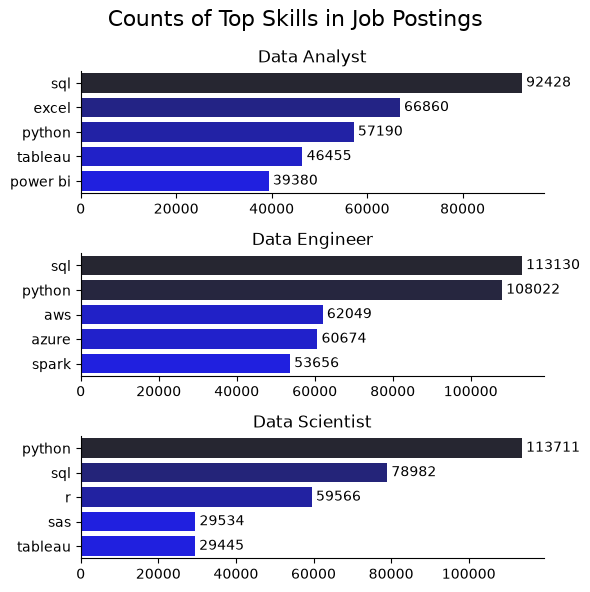

In [38]:
top_jobs_list = df['job_title_short'].value_counts().head(3).index.to_list()
print(top_jobs_list)
#df_top_jobs = df.loc[df['job_title_short'].isin(top_jobs_list)]


df_copy = df.copy()
df_copy['job_skills'] = df_copy['job_skills'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_exploded = df_copy.explode('job_skills')


fig, ax = plt.subplots(3, 1, figsize=(6, 6))


for i, job in enumerate(top_jobs_list):

    skill_counts = ( df_exploded.loc[ df_exploded['job_title_short'] == job, 'job_skills' ] .value_counts() .head(5).reset_index() )

    skill_counts.columns = ['job_skills', 'skill_count']

    sns.barplot(
        data=skill_counts,
        x='skill_count',
        y='job_skills',
        hue='skill_count',
        palette='dark:b_r',
        legend=False,
        ax=ax[i]
    )

    # Add values at the end of the bars
    for container in ax[i].containers:
        ax[i].bar_label(container, padding=3)

    ax[i].set_title(job)

    # Remove x and y axis titles
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')

    sns.despine(ax=ax[i])


fig.suptitle(
    'Counts of Top Skills in Job Postings',
    fontsize=16
)

plt.tight_layout()
plt.show()



  job_title_short  jobs_total
0    Data Analyst      196075
1   Data Engineer      186241
2  Data Scientist      172286


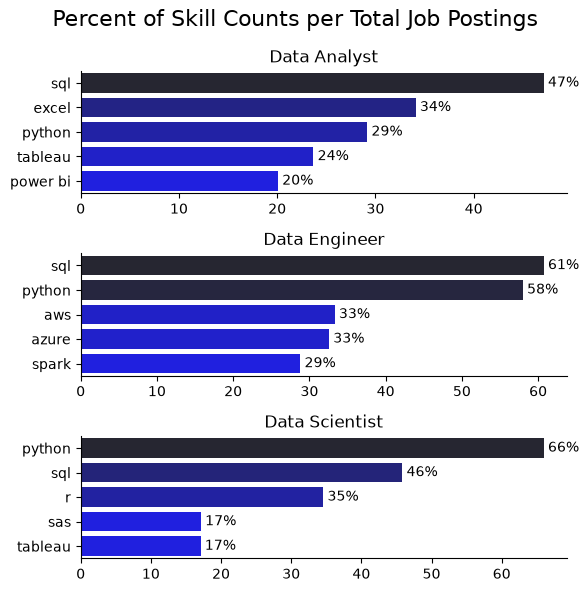

In [49]:
top_jobs = df['job_title_short'].value_counts().reset_index(name='jobs_total').head(3)
top_jobs_list = top_jobs['job_title_short'].to_list()
top_jobs_values = top_jobs['jobs_total'].to_list()
print(top_jobs) 


df_copy = df.copy()
df_copy['job_skills'] = df_copy['job_skills'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_exploded = df_copy.explode('job_skills')


fig, ax = plt.subplots(3, 1, figsize=(6, 6))


for i, job in enumerate(top_jobs_list):

    skill_counts = ( df_exploded.loc[ df_exploded['job_title_short'] == job, 'job_skills' ] .value_counts() .head(5).reset_index() )

    skill_counts.columns = ['job_skills', 'skill_count']

    skill_counts['skill_percent'] = (skill_counts['skill_count'] / top_jobs_values[i] * 100
)

    sns.barplot(
        data=skill_counts,
        x='skill_percent',
        y='job_skills',
        hue='skill_count',
        palette='dark:b_r',
        legend=False,
        ax=ax[i]
    )

    # Add values at the end of the bars
    for container in ax[i].containers:
        ax[i].bar_label(container, fmt='%.0f%%', padding=3)

    ax[i].set_title(job)

    # Remove x and y axis titles
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')

    sns.despine(ax=ax[i])


fig.suptitle(
    'Percent of Skill Counts per Total Job Postings',
    fontsize=16
)

plt.tight_layout()
plt.show()

